# 미니프로젝트: 앙상블 모델링 (Vibe Coding)

#### <목표>
Day 3에서 배운 **Random Forest, GBM, XGBoost, LightGBM, CatBoost**를 Day 2와 **동일한 제조 데이터셋**에 적용해 봅니다.

- Day 1에서의 EDA, 전처리를 복습해보고
- Day 2에서 배웠던 다중선형회귀·Ridge·Lasso·의사결정나무로 만든 결과와 비교하면서
- Day 3에서 배운 앙상블 모델이 단일 모델 대비 어떤 성능 차이를 보이는지 확인해봅니다.

#### <데이터셋 소개>

**1) 회귀용 — Mining Process Flotation Plant (광물 선광 공정 데이터)**
- 철광석을 선광(flotation)하는 공정에서 1시간 간격으로 수집된 실제 산업 데이터
- 공정 변수로 최종 정광의 불순물(실리카) 비율을 예측

| 변수명 | 설명 |
|:---:|:---|
| date | 측정 일시 |
| % Iron Feed, % Silica Feed | 투입 원광의 철/실리카 품위 |
| Starch Flow, Amina Flow | 전분/아민 투입량 (시약) |
| Ore Pulp Flow, pH, Density | 광액 유량/산도/밀도 |
| Flotation Column 01~07 Air Flow | 플로테이션 컬럼별 공기 유량 |
| Flotation Column 01~07 Level | 플로테이션 컬럼별 액위 |
| % Iron Concentrate | 최종 정광의 철 비율 (실험실 측정) |
| **% Silica Concentrate** | **최종 정광의 실리카(불순물) 비율 — 회귀 타겟** |

**2) 분류용 — Steel Plates Faults (철강 표면 결함 검사 데이터)**
- 철강판 표면을 촬영해 측정한 결함의 위치/크기/광도 등으로 결함 유형을 분류하는 실제 품질검사 데이터

| 변수명 | 설명 |
|:---:|:---|
| X/Y_Minimum, X/Y_Maximum | 결함의 위치 범위 |
| Pixels_Areas, X/Y_Perimeter | 결함의 면적·둘레 |
| Sum/Minimum/Maximum_of_Luminosity | 결함 부위의 광도 |
| Length_of_Conveyer, Steel_Plate_Thickness | 설비/소재 정보 |
| TypeOfSteel_A300, TypeOfSteel_A400 | 철강 타입 |
| Edges_Index, Square_Index, Luminosity_Index 등 | 결함 형태 특징 지수 |
| Pastry, Z_Scratch, K_Scatch, Stains, Dirtiness, Bumps, Other_Faults | 결함 유형 |
| **K_Scatch** | **긴 스크래치성 결함 여부 — 분류 타겟** |

#### <실습 태스크>
| 태스크 | 데이터 파일 | 타겟 변수 | 사용 모델 |
|:---:|:---:|:---:|:---|
| 회귀 | `dataset/day2_miniproject_reg.csv` | `% Silica Concentrate` | Random Forest, GBM, XGBoost, LightGBM, CatBoost (회귀) |
| 분류 | `dataset/day2_miniproject_cls.csv` | `K_Scatch` | Random Forest, GBM, XGBoost, LightGBM, CatBoost (분류) |

#### <진행 순서>
**Part A(회귀)** 를 데이터 불러오기 → 탐색 → 전처리 → 모델링 → 예측 → 고도화 → 결과 해석까지 **끝까지 완료한 뒤**, **Part B(분류)** 를 동일한 흐름으로 진행합니다.

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

**[과제]** 써니는 Day 2에서 사용한 회귀 및 분류 데이터셋에 다양한 트리 기반 앙상블 모델을 적용해 보려고 합니다. 분석 준비와 데이터 전처리뿐만 아니라, 앙상블 모델 구축 및 하이퍼파라미터 탐색에 필요한 라이브러리를 AI와 상의하여 선정하고 불러오는 코드를 작성해 보세요.

In [ ]:
<프롬프트>

내가 데이터 분석 및 모델링을 할 때 필요한 라이브러리들을 import 하고 싶어.
특히 회귀에서는 다중선형회귀, Ridge, Lasso, 회귀나무를 쓸거고 분류에서는 로지스틱 회귀, 분류 나무를 쓸거야
그리고 회귀랑 분류 둘다 Random Forest, GBM, XGBoost, LGBM, CatBoost를 쓸거야.
필요한 코드 짜줘.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"   # Windows 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False       # 마이너스 기호 깨짐 방지

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# 회귀 모델
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from catboost import CatBoostRegressor, CatBoostClassifier

# 분류 모델
from sklearn.linear_model import LogisticRegression

# 평가 지표
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

---
# Part A. 회귀 태스크 — Mining Process Flotation Plant

## A-0) 데이터 불러오기

**[과제]** 써니는 Day 2에서 사용했던 `dataset/day2_miniproject_reg.csv` 파일을 그대로 불러오려고 합니다. 적절한 변수명으로 데이터프레임을 만들어 보세요.

In [2]:
Regression = pd.read_csv('dataset/day2_miniproject_reg.csv')
Regression

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,3/29/2017 12:00,60.18,9.34,1060.859297,379.836203,400.982539,9.527187,1.550374,200.035839,195.577700,...,249.992956,753.724247,726.559437,860.557818,477.349197,452.512522,478.219647,470.105547,66.44,1.36
1,3/29/2017 13:00,60.18,9.34,2034.926525,322.233975,400.468947,9.700679,1.532017,199.990122,195.106250,...,250.059711,848.675503,777.784437,869.419421,483.816131,469.448172,471.607075,462.665478,66.57,1.43
2,3/29/2017 14:00,60.18,9.34,1435.425811,474.656322,399.157083,9.687788,1.645200,200.019311,195.604928,...,250.111328,851.951492,776.293654,879.704989,456.147231,453.227000,447.708467,453.475667,66.64,1.33
3,3/29/2017 15:00,60.18,9.34,618.460387,396.377733,398.942522,9.851689,1.559929,199.940833,195.657094,...,250.028506,855.910630,780.369869,882.093896,449.410744,448.581506,450.697578,448.660094,66.41,1.27
4,3/29/2017 16:00,59.54,9.56,1367.502858,317.134072,400.836283,9.936163,1.530984,199.878922,196.162864,...,250.122067,851.603513,784.446084,884.840698,450.123050,451.774694,451.574422,449.406894,63.63,5.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3943,9/9/2017 19:00,49.75,23.20,3327.047776,497.211189,380.847200,9.176166,1.660871,301.565561,300.169133,...,298.736661,397.781583,498.753311,403.858956,398.930467,502.971728,399.468911,400.559511,65.05,1.65
3944,9/9/2017 20:00,49.75,23.20,4225.800333,508.963856,381.112889,9.387541,1.691996,300.050172,299.967839,...,303.599269,399.928567,499.648950,399.208611,399.967122,501.624533,398.905006,400.486233,64.83,1.71
3945,9/9/2017 21:00,49.75,23.20,2808.214692,517.748822,381.064411,9.771277,1.735647,299.814289,299.801561,...,309.875439,399.961433,500.484917,471.827489,399.931033,500.223311,401.899806,400.556333,64.29,1.80
3946,9/9/2017 22:00,49.75,23.20,3191.497672,492.511228,380.445006,9.782121,1.716644,300.122756,299.679472,...,305.254558,399.601383,498.614494,836.277192,400.455389,500.406239,402.703283,401.769072,64.25,1.96


---
## A-1) 데이터 탐색 (EDA)

### A-1-1) Value 기반 탐색

**[과제]** 써니는 오늘도 모델링에 앞서 데이터 상태를 다시 한번 점검하고 싶습니다. AI와 함께 데이터 구조, 결측치, 수집 기간 등 기본적인 특성을 다시 확인해 보세요.

In [ ]:
[프롬프트]

회귀 데이터셋을 불러와서 Regression이라는 변수명으로 저장했어.
데이트를 분석하기 전에 Value 기반 EDA를 하고 싶어.
데이터 구조, 결측치, 통계적 정보 등을 알 수 있는 코드 짜줘.

In [3]:
# 데이터 구조 확인
print("데이터 크기 :", Regression.shape)
Regression.head()

데이터 크기 : (3948, 24)


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,3/29/2017 12:00,60.18,9.34,1060.859297,379.836203,400.982539,9.527187,1.550374,200.035839,195.577700,...,249.992956,753.724247,726.559437,860.557818,477.349197,452.512522,478.219647,470.105547,66.44,1.36
1,3/29/2017 13:00,60.18,9.34,2034.926525,322.233975,400.468947,9.700679,1.532017,199.990122,195.106250,...,250.059711,848.675503,777.784437,869.419421,483.816131,469.448172,471.607075,462.665478,66.57,1.43
2,3/29/2017 14:00,60.18,9.34,1435.425811,474.656322,399.157083,9.687788,1.645200,200.019311,195.604928,...,250.111328,851.951492,776.293654,879.704989,456.147231,453.227000,447.708467,453.475667,66.64,1.33
3,3/29/2017 15:00,60.18,9.34,618.460387,396.377733,398.942522,9.851689,1.559929,199.940833,195.657094,...,250.028506,855.910630,780.369869,882.093896,449.410744,448.581506,450.697578,448.660094,66.41,1.27
4,3/29/2017 16:00,59.54,9.56,1367.502858,317.134072,400.836283,9.936163,1.530984,199.878922,196.162864,...,250.122067,851.603513,784.446084,884.840698,450.123050,451.774694,451.574422,449.406894,63.63,5.50


In [4]:
# 컬럼별 데이터 타입 및 결측치 개수
Regression.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3948 entries, 0 to 3947
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   date                          3948 non-null   object 
 1   % Iron Feed                   3948 non-null   float64
 2   % Silica Feed                 3948 non-null   float64
 3   Starch Flow                   3948 non-null   float64
 4   Amina Flow                    3948 non-null   float64
 5   Ore Pulp Flow                 3948 non-null   float64
 6   Ore Pulp pH                   3948 non-null   float64
 7   Ore Pulp Density              3948 non-null   float64
 8   Flotation Column 01 Air Flow  3948 non-null   float64
 9   Flotation Column 02 Air Flow  3948 non-null   float64
 10  Flotation Column 03 Air Flow  3948 non-null   float64
 11  Flotation Column 04 Air Flow  3948 non-null   float64
 12  Flotation Column 05 Air Flow  3948 non-null   float64
 13  Flo

In [5]:
# 결측치 개수 및 비율
missing = Regression.isnull().sum()
missing_ratio = (missing / len(Regression) * 100).round(2)
pd.DataFrame({"결측치 개수": missing, "결측치 비율(%)": missing_ratio}).sort_values(by="결측치 개수", ascending=False)

,결측치 개수,결측치 비율(%)
date,0,0.0
% Iron Feed,0,0.0
% Silica Feed,0,0.0
Starch Flow,0,0.0
Amina Flow,0,0.0
Ore Pulp Flow,0,0.0
Ore Pulp pH,0,0.0
Ore Pulp Density,0,0.0
Flotation Column 01 Air Flow,0,0.0
Flotation Column 02 Air Flow,0,0.0


In [6]:
# 수치형 변수 기술통계
Regression.describe()

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
count,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,...,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000
mean,56.220301,14.767789,2847.012956,488.720690,397.471417,9.769643,1.679042,281.287417,278.182019,282.253076,...,292.293595,520.425277,523.195899,532.182319,418.095661,422.776652,426.996977,418.128753,65.027176,2.322261
std,5.231150,6.887711,948.913479,83.769854,8.491449,0.378012,0.063417,29.361843,29.490104,28.244196,...,26.527575,123.756672,116.664614,140.549112,76.142141,74.612107,74.714161,71.636366,1.109367,1.120117
min,42.740000,1.310000,54.595483,242.927477,376.837604,8.753389,1.519926,175.885579,178.188430,177.202665,...,199.728122,181.925623,224.909663,135.214506,165.725058,214.735894,203.702926,185.061388,62.050000,0.600000
25%,52.610000,8.812500,2146.232398,436.428747,398.774394,9.542790,1.649868,250.109688,250.119040,250.109164,...,299.031694,409.067986,449.187215,402.250428,351.264361,350.829644,353.171861,350.734692,64.350000,1.440000
50%,55.940000,14.200000,2880.359057,502.685958,399.835435,9.796511,1.694900,299.850578,299.596767,299.893233,...,299.876333,499.582128,499.840739,499.584794,400.834364,400.626158,402.707483,400.495361,65.190000,2.000000
75%,59.720000,20.140000,3514.789671,550.144572,400.592916,10.033416,1.719869,299.955660,299.991808,299.948658,...,300.129489,599.849921,599.424594,600.303602,494.603949,497.296990,489.623260,454.574938,65.830000,2.992500
max,65.780000,33.400000,6270.158798,736.982378,418.070232,10.807370,1.818191,312.295415,309.887767,302.783000,...,351.268656,859.025062,827.775874,884.840698,675.631942,674.068176,698.505832,655.501603,68.010000,5.530000


In [7]:
# 중복 행 확인
print("중복 행 개수 :", Regression.duplicated().sum())

중복 행 개수 : 0


### A-1-2) Graph 기반 탐색

**[과제]** 써니는 오늘도 어제처럼 시계열 변화 패턴과 변수 간 상관관계를 앙상블 모델링 전에 다시 시각화로 점검하려고 합니다. AI와 함께 시간 흐름에 따른 변수 변화를 시각화해 보세요.

In [ ]:
[프롬프트]

1. 데이터 내 변수들을 분포를 알고싶은데 subplot 형태로 그릴 수 있는 코드 짜줘.
2. 시간에 따라 변수들의 분포를 파악해서 시계열적 특성이 있는지 알고싶어. 관련 코드 짜줘.
3. 변수간 상관관계를 알 수 있는 코드 짜줘.

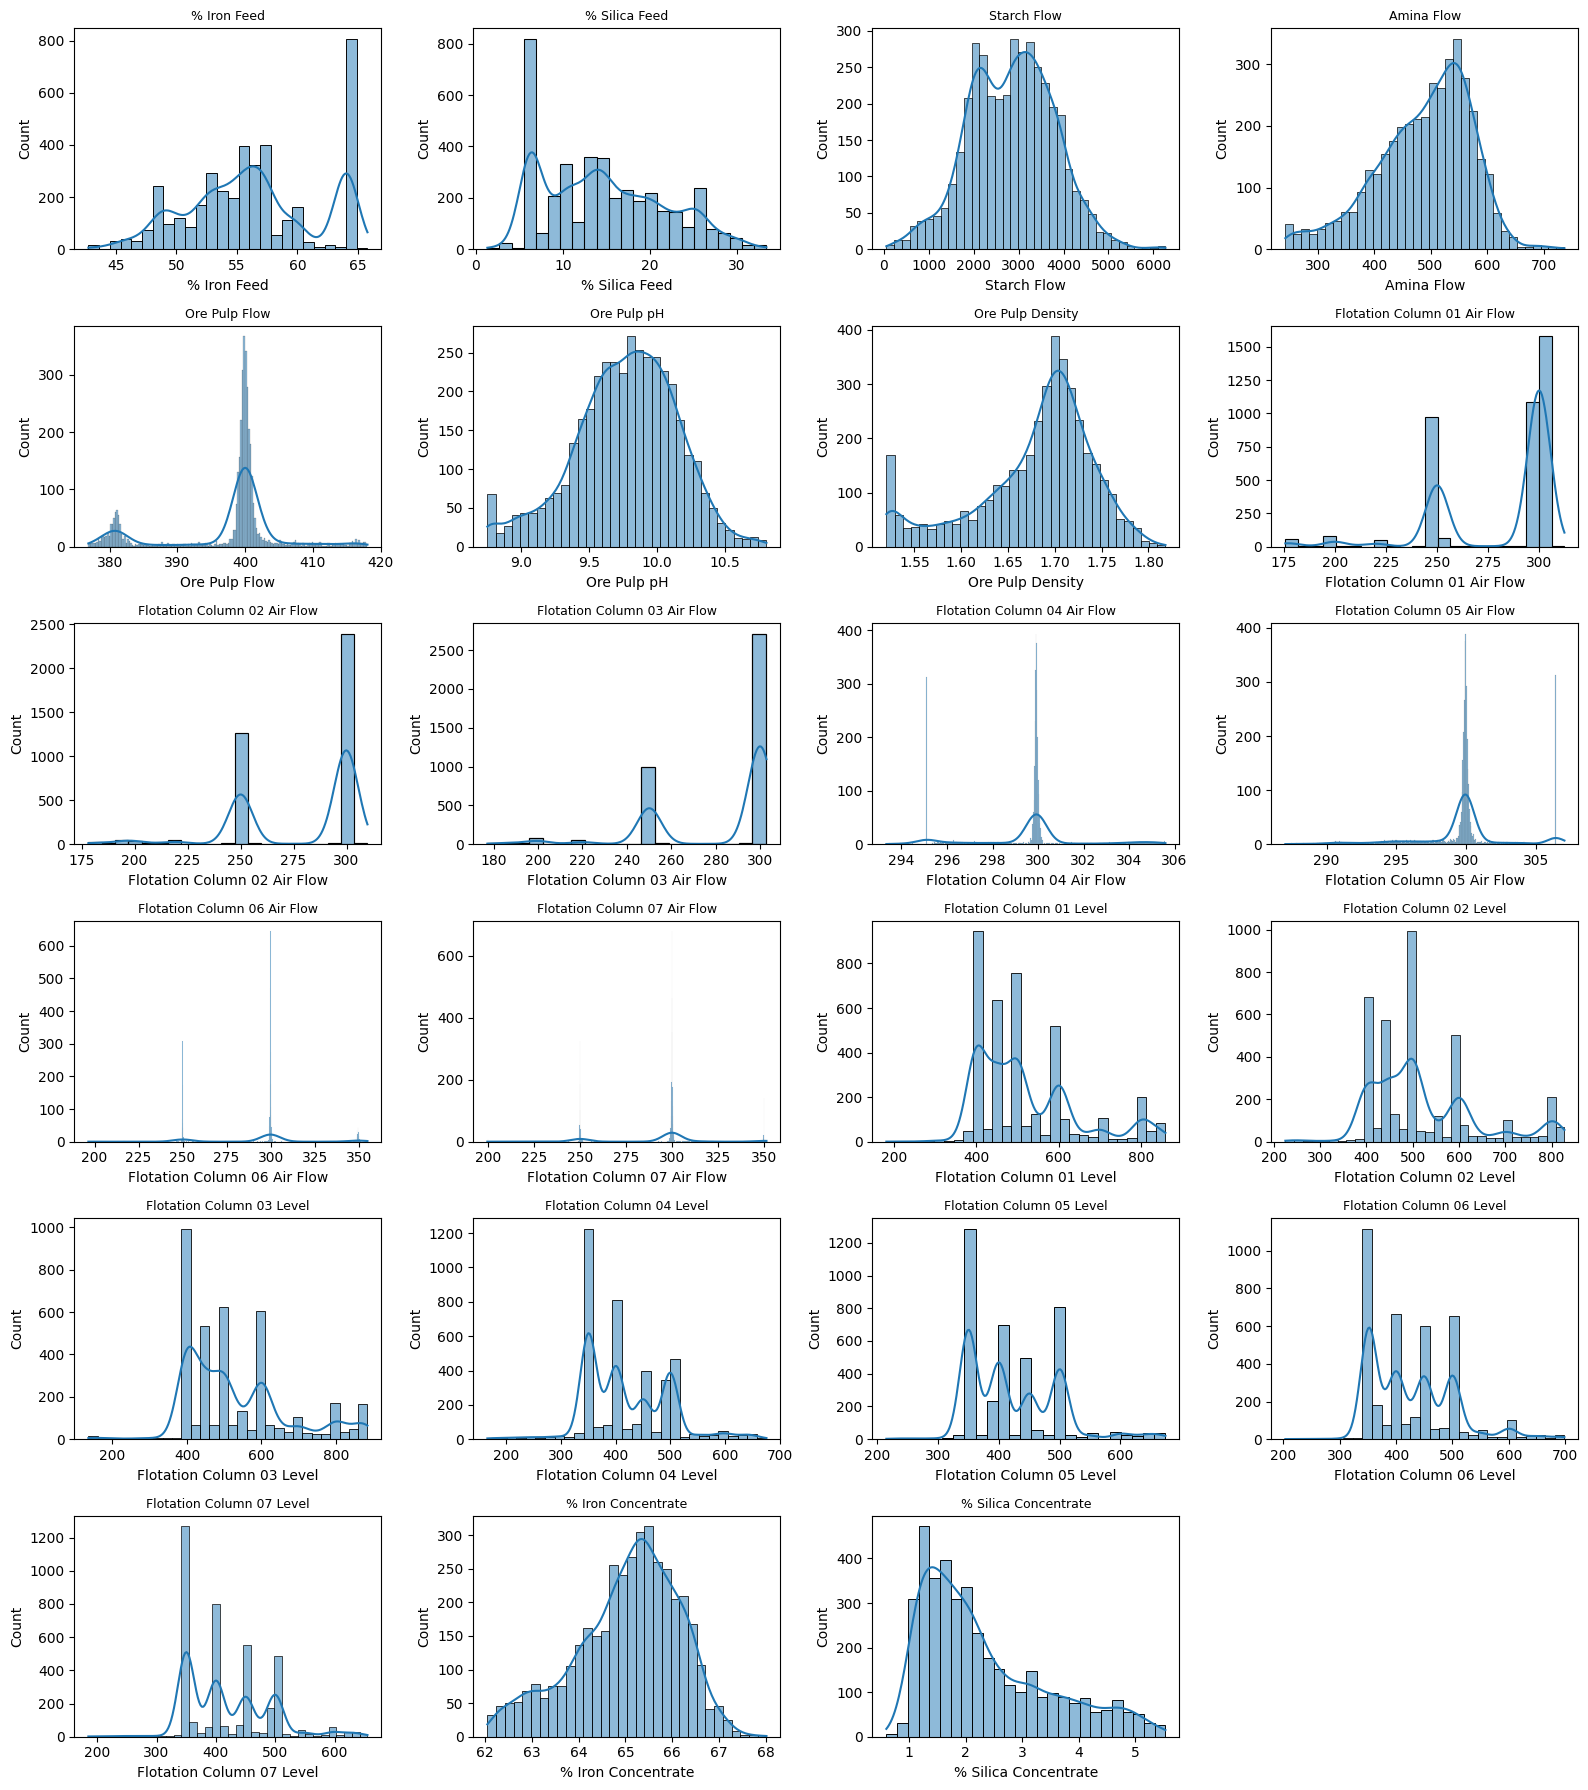

In [8]:
# 1. 변수별 분포 (subplot)
numeric_cols = Regression.select_dtypes(include=np.number).columns

n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(Regression[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=9)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


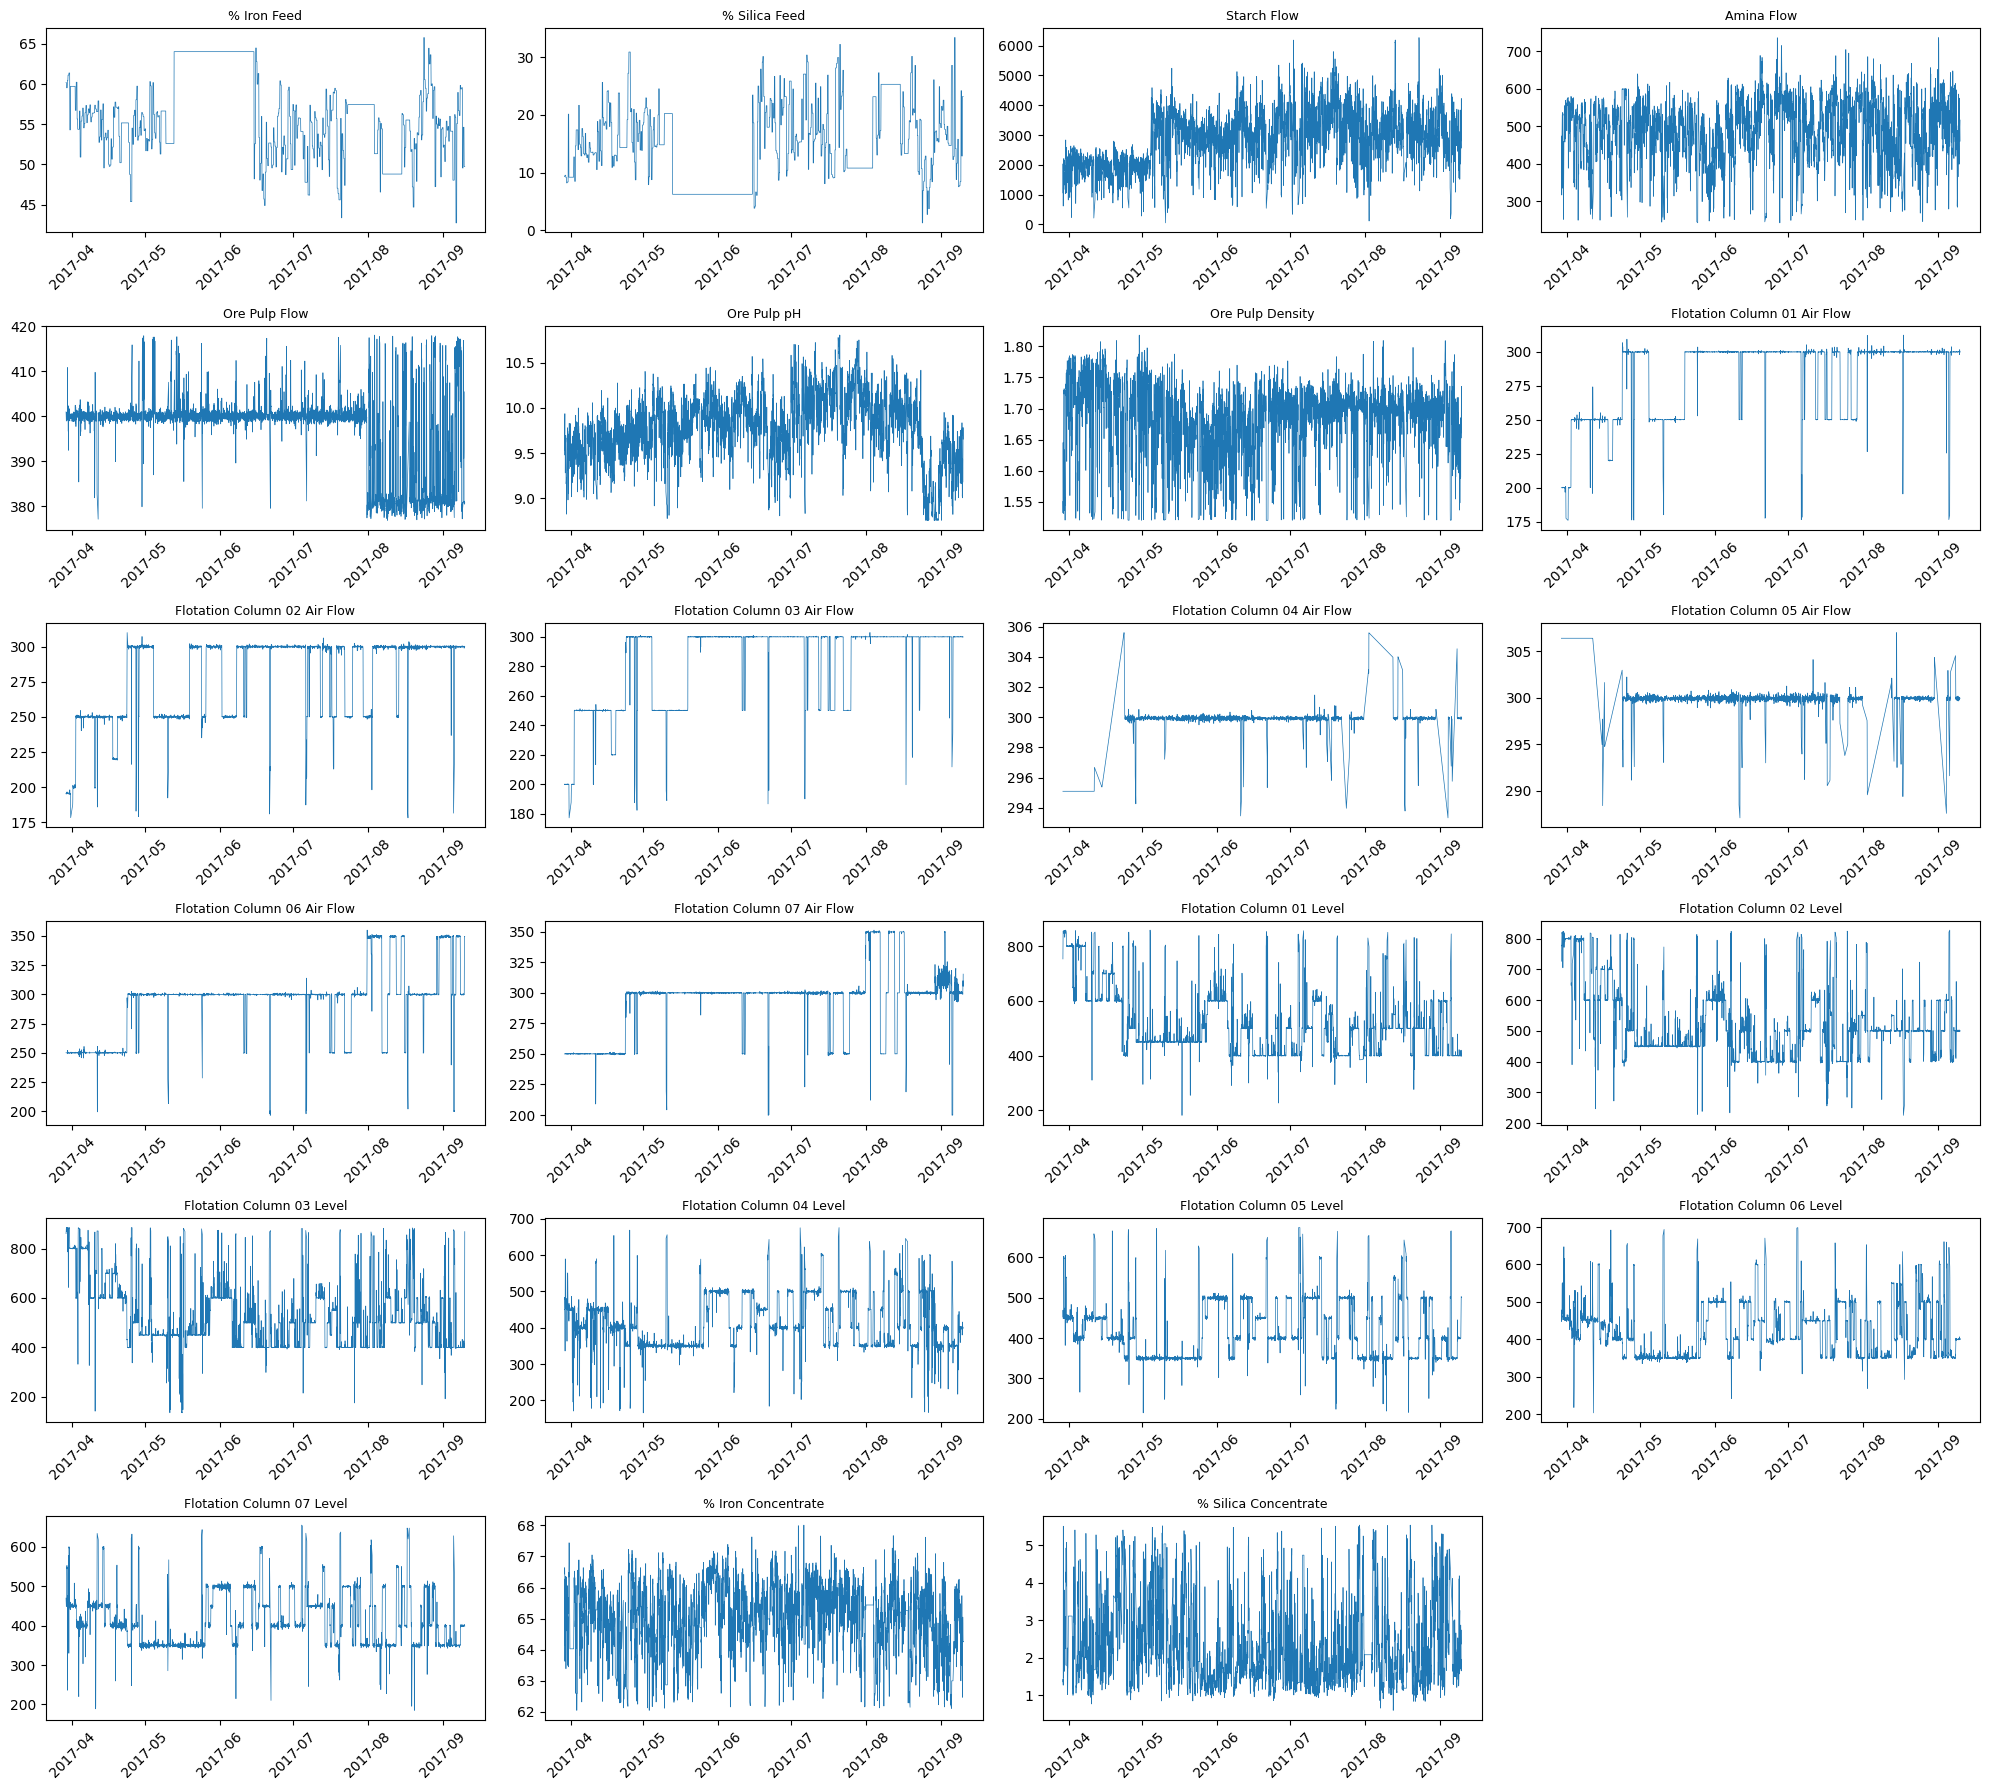

In [9]:
# 2. 시간에 따른 변수 분포 (시계열 특성 파악)
Regression["date"] = pd.to_datetime(Regression["date"])
Regression_sorted = Regression.sort_values("date")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].plot(Regression_sorted["date"], Regression_sorted[col], linewidth=0.5)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis="x", rotation=45)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


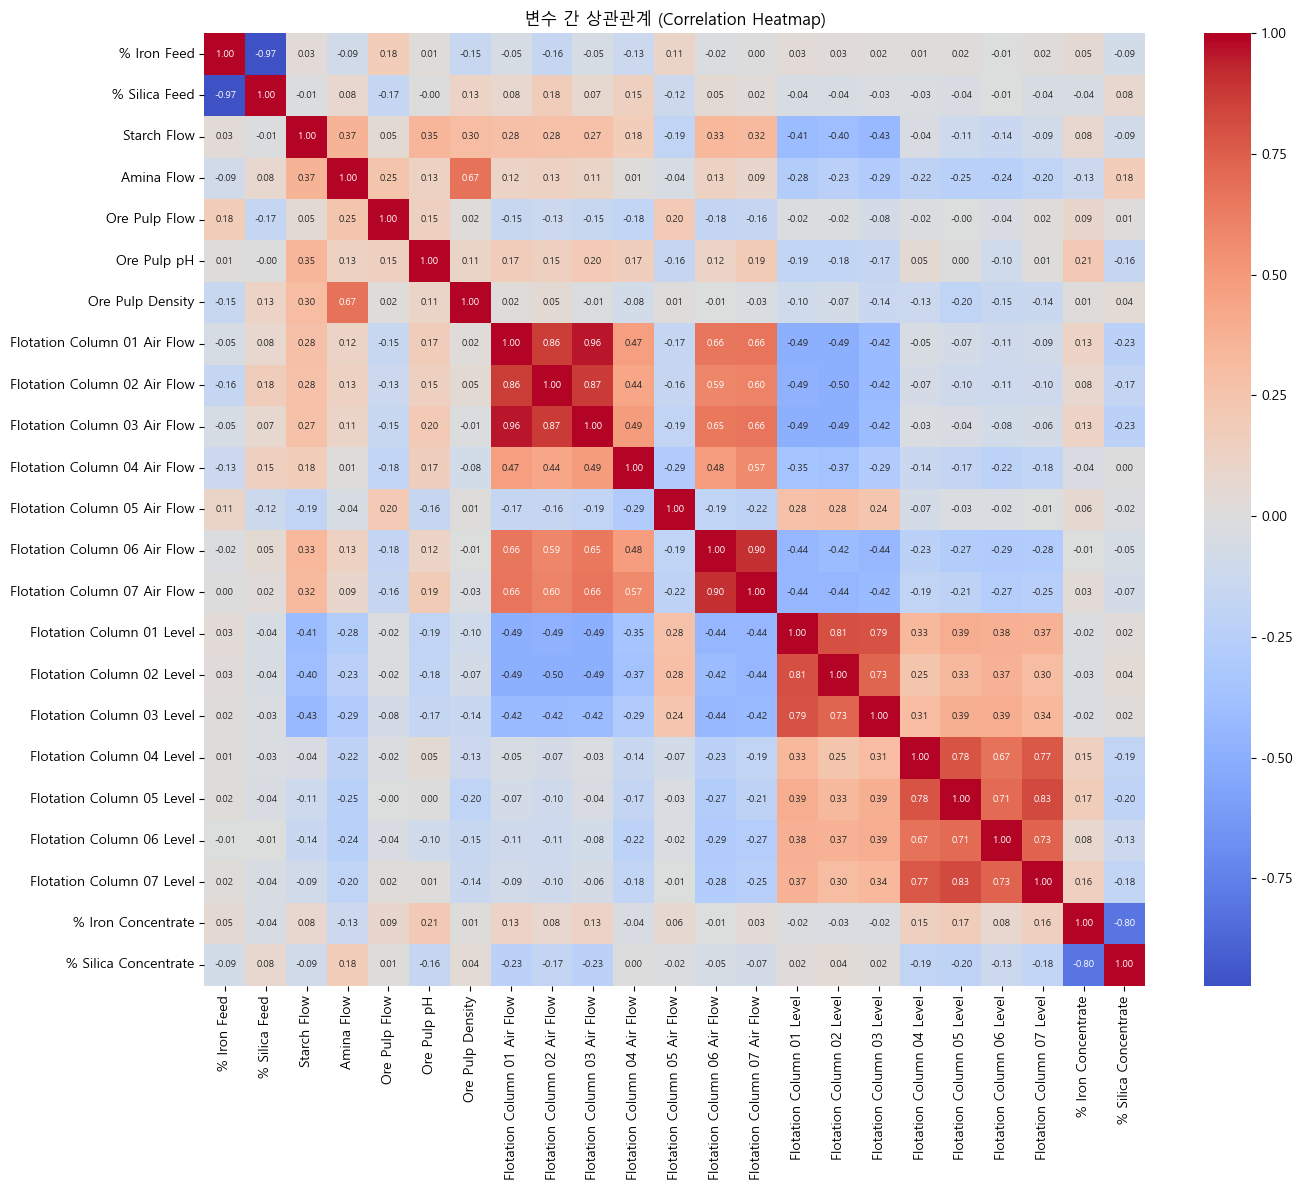

In [12]:
# 3. 변수 간 상관관계
corr = Regression[numeric_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size": 7})
plt.title("변수 간 상관관계 (Correlation Heatmap)")
plt.tight_layout()
plt.show()

**[과제]** 써니는 변수들 간에 강하게 얽혀 있는 관계(다중공선성 후보)가 있는지 한눈에 살펴보고 싶습니다. AI와 상의해서 상관관계 히트맵을 그려보고 트리 기반 앙상블 모델에서는 이 다중공선성이 Day 2의 선형 모델만큼 문제가 되는지도 함께 생각해 보세요.

In [ ]:
[프롬프트]

일부 변수들에 강한 선형관계가 존재하는데 그 후보를 출력할 수 있는 코드 짜줘.
이때 "강하다"라고 판단할만할 기준치를 추천해줘.

In [ ]:
# 상관계수 절댓값이 임계값 이상인 변수쌍 후보 추출
threshold = 0.8

corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["Variable_1", "Variable_2", "Correlation"]
corr_pairs["Abs_Correlation"] = corr_pairs["Correlation"].abs()

strong_corr = corr_pairs[corr_pairs["Abs_Correlation"] >= threshold].sort_values(
    by="Abs_Correlation", ascending=False
).reset_index(drop=True)

print(f"강한 선형관계 후보 (|상관계수| >= {threshold}) : {len(strong_corr)}쌍")
strong_corr

강한 선형관계 후보 (|상관계수| >= 0.8) : 8쌍


,Variable_1,Variable_2,Correlation,Abs_Correlation
0,% Iron Feed,% Silica Feed,-0.972047,0.972047
1,Flotation Column 01 Air Flow,Flotation Column 03 Air Flow,0.958320,0.958320
2,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,0.902963,0.902963
3,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,0.874899,0.874899
4,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,0.861870,0.861870
5,Flotation Column 05 Level,Flotation Column 07 Level,0.829773,0.829773
6,Flotation Column 01 Level,Flotation Column 02 Level,0.807179,0.807179
7,% Iron Concentrate,% Silica Concentrate,-0.802749,0.802749


---
## A-2) 데이터 전처리

### A-2-1) 불필요한 변수 제거 및 결측치 확인

**[과제]** 써니는 Heatmap을 통해 타겟변수와 강한 상관관계를 가지는 변수를 발견하였습니다. 해당 변수가 데이터 누수를 유발할 수 있는지가 궁금해졌습니다. AI와 함께 상의하여 해당 변수 제거 여부를 검토하고 결정해보세요.

In [ ]:
[프롬프트]

("강한 선형관계 후보" 출력을 복사하여)
어떤 변수들을 제거해야하는지 그 이유를 선생님처럼 쉽게 설명해줘.

In [ ]:
[프롬프트]

그러면 제거하는 코드 짜줘.

In [14]:
# 데이터 누수 위험이 있는 % Iron Concentrate 제거
Regression = Regression.drop(columns=["% Iron Concentrate"])

print("제거 후 데이터 크기 :", Regression.shape)
Regression.columns

제거 후 데이터 크기 : (3948, 23)


Index(['date', '% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow',
       'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density',
       'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow',
       'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow',
       'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow',
       'Flotation Column 07 Air Flow', 'Flotation Column 01 Level',
       'Flotation Column 02 Level', 'Flotation Column 03 Level',
       'Flotation Column 04 Level', 'Flotation Column 05 Level',
       'Flotation Column 06 Level', 'Flotation Column 07 Level',
       '% Silica Concentrate'],
      dtype='object')

### A-2-2) 입출력 변수 분할 및 데이터 분할

**[과제]** 써니는 `% Silica Concentrate`를 예측하기 위해 입력변수와 타겟 변수를 분리하려고 합니다. Day 2와 마찬가지로 시계열 데이터라는 점을 고려하여 데이터를 분할해보세요.

In [ ]:
[프롬프트]

데이터가 시간에 따라 수집된 데이터인 것 같아. 이럴 땐 어떻게 분리하는게 적합해?

In [ ]:
[프롬프트]

EDA 할 때 변수별 시간에 따른 패턴을 시각화했는데 시간적 정보를 가지고 있는지 잘 모르겠어.

1. 알 수 있는 방법을 아주 쉽게 알려주고
2. 관련된 코드 짜주고
3. 결과가 나왔을 때 어떻게 판단하면 될지도 알려줘.

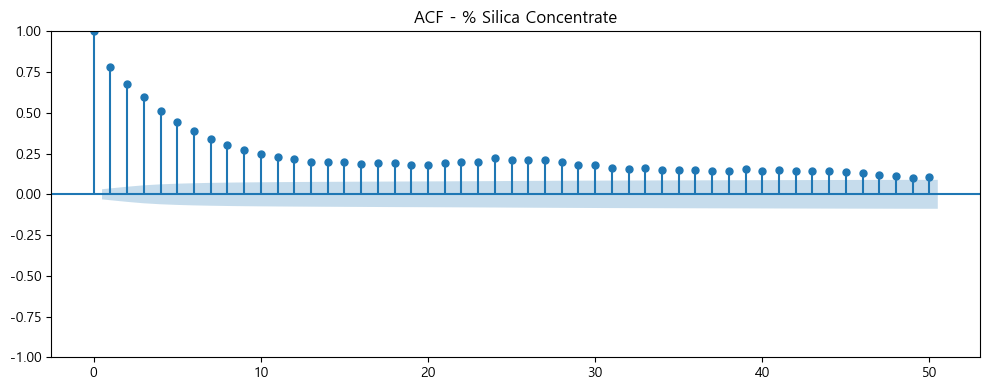

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

# 시간 순 정렬 (이미 정렬했다면 생략 가능)
Regression_sorted = Regression.sort_values("date")

# 타겟 변수 ACF
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(Regression_sorted["% Silica Concentrate"], lags=50, ax=ax)
ax.set_title("ACF - % Silica Concentrate")
plt.tight_layout()
plt.show()

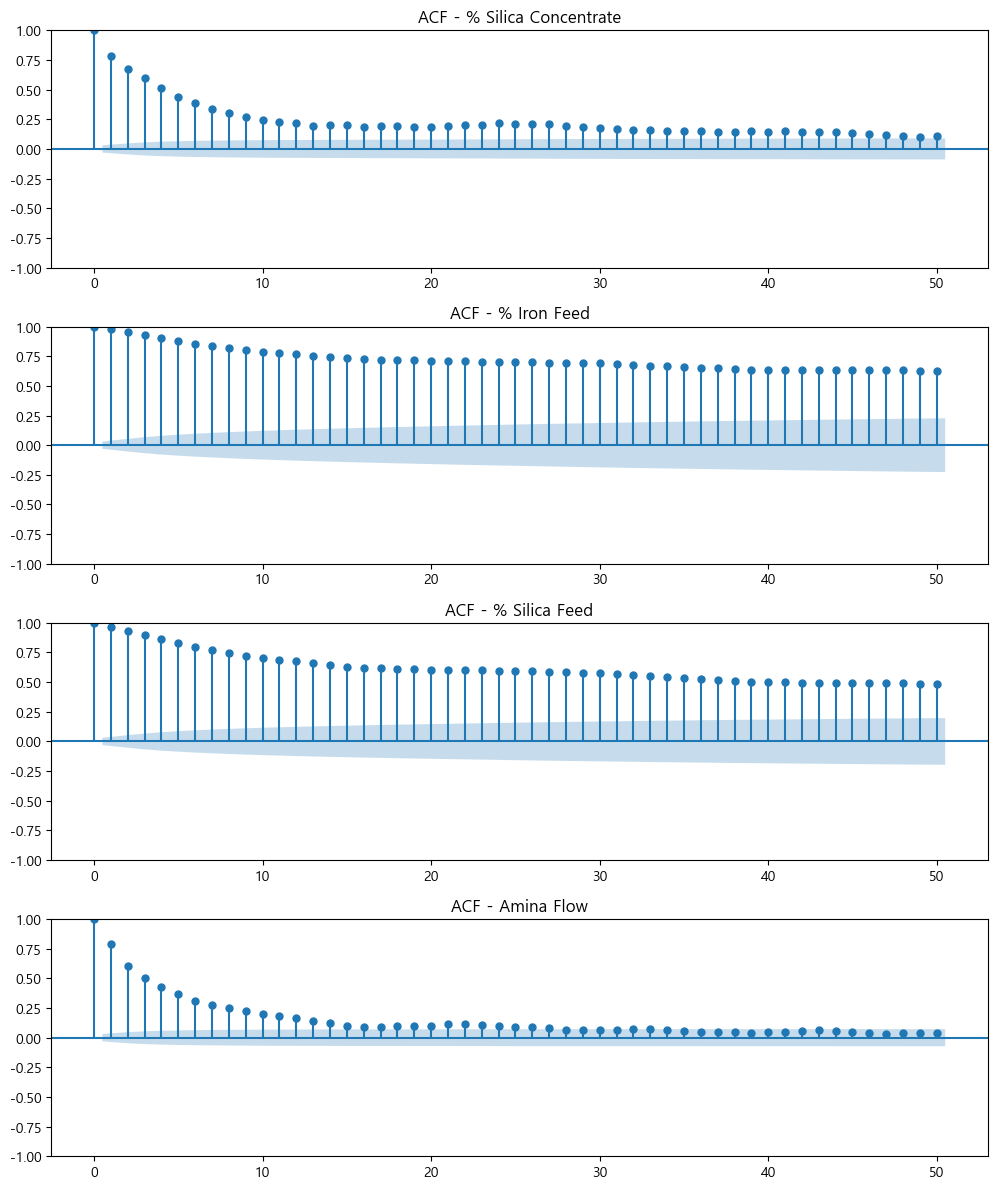

In [ ]:
# 여러 변수 ACF를 한눈에 비교 (subplot)
cols_to_check = ["% Silica Concentrate", "% Iron Feed", "% Silica Feed", "Amina Flow"]  # 확인하고 싶은 변수로 수정

fig, axes = plt.subplots(len(cols_to_check), 1, figsize=(10, 3 * len(cols_to_check)))

for ax, col in zip(axes, cols_to_check):
    plot_acf(Regression_sorted[col], lags=50, ax=ax)
    ax.set_title(f"ACF - {col}")

plt.tight_layout()
plt.show()

In [17]:
# 시간 순 정렬 후 앞부분(과거) = 학습, 뒷부분(미래) = 테스트로 분할
Regression_sorted = Regression.sort_values("date").reset_index(drop=True)

Y_reg = Regression_sorted["% Silica Concentrate"]
X_reg = Regression_sorted.drop(columns=["% Silica Concentrate", "date"])

X_train_reg, X_test_reg, Y_train_reg, Y_test_reg = train_test_split(
    X_reg, Y_reg, test_size=0.3, shuffle=False
)

print("학습 데이터 :", X_train_reg.shape)
print("테스트 데이터 :", X_test_reg.shape)
print("학습 기간 :", Regression_sorted.loc[X_train_reg.index, "date"].min(), "~", Regression_sorted.loc[X_train_reg.index, "date"].max())
print("테스트 기간 :", Regression_sorted.loc[X_test_reg.index, "date"].min(), "~", Regression_sorted.loc[X_test_reg.index, "date"].max())

학습 데이터 : (2763, 21)
테스트 데이터 : (1185, 21)
학습 기간 : 2017-03-29 12:00:00 ~ 2017-07-22 14:00:00
테스트 기간 : 2017-07-22 15:00:00 ~ 2017-09-09 23:00:00


### A-2-3) 스케일링 필요 여부 검토

**[과제]** 써니는 Day 2에서는 Ridge/Lasso 모델 특성 때문에 StandardScaler를 적용했었는데 Day 3에서 사용할 Random Forest·GBM·XGBoost·LightGBM·CatBoost도 스케일링이 꼭 필요한지 AI와 상의해서 판단해 보세요.

In [ ]:
[프롬프트]

스케일링을 하려고 하는데 변수의 타입을 보고 판단하고 싶어. 볼 수 있는 코드 좀 짜줘.

In [ ]:
# 변수 타입 확인
print(X_reg.dtypes)
print()

# dtype별 변수 개수
print("dtype별 변수 개수")
print(X_reg.dtypes.value_counts())
print()

# 수치형 / 범주형(object, category) 변수 목록 분리
numeric_cols = X_reg.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_reg.select_dtypes(include=["object", "category"]).columns.tolist()

print("수치형 변수 (%d개) :" % len(numeric_cols), numeric_cols)
print("범주형 변수 (%d개) :" % len(categorical_cols), categorical_cols)

% Iron Feed                     float64
% Silica Feed                   float64
Starch Flow                     float64
Amina Flow                      float64
Ore Pulp Flow                   float64
Ore Pulp pH                     float64
Ore Pulp Density                float64
Flotation Column 01 Air Flow    float64
Flotation Column 02 Air Flow    float64
Flotation Column 03 Air Flow    float64
Flotation Column 04 Air Flow    float64
Flotation Column 05 Air Flow    float64
Flotation Column 06 Air Flow    float64
Flotation Column 07 Air Flow    float64
Flotation Column 01 Level       float64
Flotation Column 02 Level       float64
Flotation Column 03 Level       float64
Flotation Column 04 Level       float64
Flotation Column 05 Level       float64
Flotation Column 06 Level       float64
Flotation Column 07 Level       float64
dtype: object

dtype별 변수 개수
float64    21
Name: count, dtype: int64

수치형 변수 (21개) : ['% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow', 'Ore Pulp Flow

In [ ]:
[프롬프트]

확인해보니 다 수치형 변수인데 어떤 스케일링을 하는게 적합할까?
참고로 앙상블 계열 모델을 학습시킬거야.

---
## A-3) 모델 학습 및 예측

**[과제]** 써니는 Day 2에서 학습한 회귀 모델과 Day 3에서 학습한 앙상블 모델을 동일한 데이터셋에 적용하여 성능을 비교해 보고자 합니다. AI와 함께 모델 학습, 예측, 성능 평가 코드를 작성하고, 여러 모델의 결과를 한눈에 비교할 수 있는 방법을 찾아 성능을 비교 및 분석해 보세요.

In [ ]:
[프롬프트]

내가 회귀 데이터셋을 학습할 때

다중 선형회귀, Ridge, Lasso에 대해 배웠고
앙상블 모델 Random Forest, GBM, XGBoost, LGBM, CatBoost에 대해 배웠어

동일한 데이터셋에 대해 이 모든 모델을 돌리고 성능을 비교하고 싶어

1. 학습, 예측, 성능 평가하는 코드 짜주고
2. 여러 모델 결과를 한눈에 비교할 수 있는 코드 짜줘

In [19]:
from sklearn.preprocessing import StandardScaler

# 선형계열(다중회귀·Ridge·Lasso)만 스케일링, 트리/앙상블 계열은 원본 그대로 사용
scaler = StandardScaler()
X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_test_reg_scaled = scaler.transform(X_test_reg)

# 회귀 성능 평가 함수
def get_regscore(true, pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(true, pred)),
        "MAE": mean_absolute_error(true, pred),
        "R-squared": r2_score(true, pred),
    }

# (모델 인스턴스, 스케일링 필요 여부)
models_reg = {
    "LinearRegression": (LinearRegression(), True),
    "Ridge": (Ridge(), True),
    "Lasso": (Lasso(), True),
    "RandomForest": (RandomForestRegressor(random_state=0), False),
    "GBM": (GradientBoostingRegressor(random_state=0), False),
    "XGBoost": (XGBRegressor(random_state=0), False),
    "LightGBM": (LGBMRegressor(random_state=0, verbose=-1), False),
    "CatBoost": (CatBoostRegressor(random_state=0, verbose=0), False),
}

reg_results = []
reg_preds = {}

for name, (model, needs_scaling) in models_reg.items():
    X_tr = X_train_reg_scaled if needs_scaling else X_train_reg
    X_te = X_test_reg_scaled if needs_scaling else X_test_reg

    model.fit(X_tr, Y_train_reg)
    pred = model.predict(X_te)
    reg_preds[name] = pred

    score = get_regscore(Y_test_reg, pred)
    score["Model"] = name
    reg_results.append(score)

    print(f"[{name}]")
    print("RMSE      : %.3f" % score["RMSE"])
    print("MAE       : %.3f" % score["MAE"])
    print("R-squared : %.3f" % score["R-squared"])
    print()

[LinearRegression]
RMSE      : 1.203
MAE       : 0.905
R-squared : -0.125

[Ridge]
RMSE      : 1.202
MAE       : 0.904
R-squared : -0.122

[Lasso]
RMSE      : 1.136
MAE       : 0.900
R-squared : -0.002

[RandomForest]
RMSE      : 1.084
MAE       : 0.868
R-squared : 0.087

[GBM]
RMSE      : 1.057
MAE       : 0.825
R-squared : 0.132

[XGBoost]
RMSE      : 1.168
MAE       : 0.911
R-squared : -0.061

[LightGBM]
RMSE      : 1.100
MAE       : 0.836
R-squared : 0.060

[CatBoost]
RMSE      : 1.080
MAE       : 0.853
R-squared : 0.093



              Model   RMSE    MAE  R-squared
0               GBM  1.057  0.825      0.132
1          CatBoost  1.080  0.853      0.093
2      RandomForest  1.084  0.868      0.087
3          LightGBM  1.100  0.836      0.060
4             Lasso  1.136  0.900     -0.002
5           XGBoost  1.168  0.911     -0.061
6             Ridge  1.202  0.904     -0.122
7  LinearRegression  1.203  0.905     -0.125


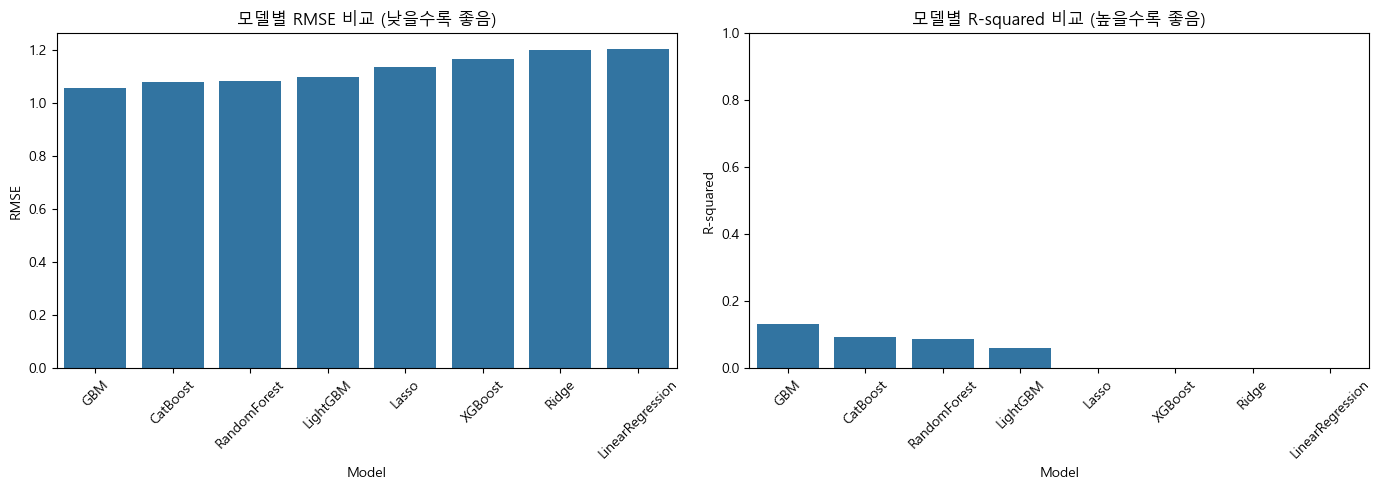

In [20]:
# 여러 모델 결과 한눈에 비교
reg_compare = pd.DataFrame(reg_results)[["Model", "RMSE", "MAE", "R-squared"]].round(3)
reg_compare = reg_compare.sort_values(by="R-squared", ascending=False).reset_index(drop=True)
print(reg_compare)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x="Model", y="RMSE", data=reg_compare, ax=axes[0])
axes[0].set_title("모델별 RMSE 비교 (낮을수록 좋음)")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(x="Model", y="R-squared", data=reg_compare, ax=axes[1])
axes[1].set_title("모델별 R-squared 비교 (높을수록 좋음)")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

---
## A-4) 모델 결과 분석 및 고도화

**[과제]** 써니는 Day 2에서 학습한 회귀 모델들과 Day 3에서 학습한 앙상블 모델들이 중요하다고 판단하는 공정 변수가 모델에 따라 얼마나 일관되게 나타나는지 궁금해졌습니다. AI와 함께 변수 중요도 및 회귀 계수를 비교할 수 있는 코드를 작성하고 여러 모델에서 공통적으로 중요하게 선정되는 핵심 공정 변수가 무엇인지 분석해 보세요.

In [ ]:
[프롬프트]

회귀모델들도 회귀계수로 변수 중요도를 알 수 있고
앙상블 모델들도 변수 중요도를 알 수 있는데

공통적으로 중요하다고 말하는 변수가 뭔지 궁금해.

알 수 있는 방법을 아주 쉽게 설명해주고 관련 코드 줘.

In [22]:
# 1. 모델별 변수 중요도 / 회귀계수(절댓값) 추출
importance_dict = {}

# 회귀계수 기반 모델 (표준화된 데이터로 학습했으므로 계수 크기끼리 비교 가능)
for name in ["LinearRegression", "Ridge", "Lasso"]:
    model = models_reg[name][0]
    importance_dict[name] = pd.Series(np.abs(model.coef_), index=X_reg.columns)

# 변수 중요도 기반 모델
for name in ["RandomForest", "GBM", "XGBoost", "LightGBM", "CatBoost"]:
    model = models_reg[name][0]
    importance_dict[name] = pd.Series(model.feature_importances_, index=X_reg.columns)

importance_df = pd.DataFrame(importance_dict)
importance_df.head()

,LinearRegression,Ridge,Lasso,RandomForest,GBM,XGBoost,LightGBM,CatBoost
% Iron Feed,0.304515,0.297906,0.0,0.034241,0.057466,0.028672,167,5.631356
% Silica Feed,0.345704,0.339428,0.0,0.047035,0.082064,0.128292,170,7.368646
Starch Flow,0.122136,0.121999,0.0,0.046637,0.032978,0.026861,148,5.261138
Amina Flow,0.298111,0.297666,0.0,0.076723,0.090567,0.053574,197,8.151467
Ore Pulp Flow,0.004149,0.004181,0.0,0.038862,0.016512,0.025421,160,3.706220


In [24]:
# 2. 선택한 방법) 8개 모델 중 Top 5 안에 몇 번이나 들었는지 카운트 (교집합 관점)
top5_count = (importance_df.rank(ascending=False) <= 5).sum(axis=1).sort_values(ascending=False)

print("8개 모델 중 Top 5 안에 든 횟수")
top5_count

8개 모델 중 Top 5 안에 든 횟수


% Silica Feed                   6
Amina Flow                      6
Flotation Column 03 Air Flow    6
Flotation Column 04 Air Flow    5
% Iron Feed                     4
Flotation Column 06 Level       2
Flotation Column 03 Level       2
Flotation Column 01 Air Flow    2
Flotation Column 07 Level       1
Ore Pulp pH                     1
Starch Flow                     0
Ore Pulp Flow                   0
Flotation Column 02 Air Flow    0
Flotation Column 06 Air Flow    0
Flotation Column 05 Air Flow    0
Ore Pulp Density                0
Flotation Column 07 Air Flow    0
Flotation Column 02 Level       0
Flotation Column 01 Level       0
Flotation Column 05 Level       0
Flotation Column 04 Level       0
dtype: int64

**[과제]** 써니는 가장 우수했던 모델의 성능을 하이퍼파라미터 튜닝으로 더 끌어올리고 싶습니다. AI와 함께 어떤 하이퍼파라미터를 어느 범위까지 탐색하면 좋을지 논의하고 GridSearchCV로 최적의 조합을 찾아 성능을 개선해 보세요.

In [ ]:
[프롬프트]

가장 우수했던 모델이 GBM이었는데 Grid Search를 통해 하이퍼파라미터 튜닝을 해서 성능을 더 올리고 싶어.

1. GBM의 주요 하이퍼파라미터의 적절한 범위를 추천해주고
2. 관련된 코드를 짜주고
3. 그 기준으로 테스트 데이터에 대해 예측하고 성능 추출해주는 코드 짜줘.

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

params_gbm_reg = {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "min_samples_leaf": [1, 5, 10],
    "subsample": [0.7, 0.8, 1.0]
}

tscv = TimeSeriesSplit(n_splits=5)

grid_gbm_reg = GridSearchCV(
    GradientBoostingRegressor(random_state=0),
    param_grid=params_gbm_reg,
    cv=tscv,
    scoring="r2",
    n_jobs=-1
)
grid_gbm_reg.fit(X_train_reg, Y_train_reg)

print("최적 파라미터:", grid_gbm_reg.best_params_)
print("최적 R-squared (CV): %.4f" % grid_gbm_reg.best_score_)

In [ ]:
# 최적 모델로 테스트 성능 평가
best_gbm_reg_pred = grid_gbm_reg.predict(X_test_reg)
best_score = get_regscore(Y_test_reg, best_gbm_reg_pred)

print("[GBM - 최적 모델]")
print("RMSE      : %.3f" % best_score["RMSE"])
print("MAE       : %.3f" % best_score["MAE"])
print("R-squared : %.3f" % best_score["R-squared"])

---
# Part B. 분류 태스크 — Steel Plates Faults

## B-0) 데이터 불러오기

**[과제]** 써니는 Day 2에서 사용했던 `dataset/day2_miniproject_cls.csv` 파일을 그대로 불러오려고 합니다. 적절한 변수명으로 데이터프레임을 만들어 보세요.

In [27]:
Classification = pd.read_csv('dataset/day2_miniproject_cls.csv')
Classification

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1936,249,277,325780,325796,273,54,22,35033,119,141,...,-0.4286,0.0026,0.7254,0,0,0,0,0,0,1
1937,144,175,340581,340598,287,44,24,34599,112,133,...,-0.4516,-0.0582,0.8173,0,0,0,0,0,0,1
1938,145,174,386779,386794,292,40,22,37572,120,140,...,-0.4828,0.0052,0.7079,0,0,0,0,0,0,1
1939,137,170,422497,422528,419,97,47,52715,117,140,...,-0.0606,-0.0171,0.9919,0,0,0,0,0,0,1


---
## B-1) 데이터 탐색 (EDA)

**[과제]** 써니는 오늘도 모델링에 앞서 데이터 상태를 다시 한번 점검하고 싶습니다. AI와 함께 데이터 구조, 결측치, 수집 기간 등 기본적인 특성을 다시 확인해 보세요.

In [ ]:
[프롬프트]

Classification이라는 데이터셋을 불러왔는데
이 데이터셋의 구조적, 통계적 정보를 알 수 있는 코드 짜줘.

In [28]:
# 데이터 구조 확인
print("데이터 크기 :", Classification.shape)
Classification.head()

데이터 크기 : (1941, 34)


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0


In [ ]:
# 컬럼별 데이터 타입 및 결측치 개수
Classification.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              1941 non-null   int64  
 1   X_Maximum              1941 non-null   int64  
 2   Y_Minimum              1941 non-null   int64  
 3   Y_Maximum              1941 non-null   int64  
 4   Pixels_Areas           1941 non-null   int64  
 5   X_Perimeter            1941 non-null   int64  
 6   Y_Perimeter            1941 non-null   int64  
 7   Sum_of_Luminosity      1941 non-null   int64  
 8   Minimum_of_Luminosity  1941 non-null   int64  
 9   Maximum_of_Luminosity  1941 non-null   int64  
 10  Length_of_Conveyer     1941 non-null   int64  
 11  TypeOfSteel_A300       1941 non-null   int64  
 12  TypeOfSteel_A400       1941 non-null   int64  
 13  Steel_Plate_Thickness  1941 non-null   int64  
 14  Edges_Index            1941 non-null   float64
 15  Empt

In [ ]:
# 결측치 개수 및 비율
missing = Classification.isnull().sum()
missing_ratio = (missing / len(Classification) * 100).round(2)
pd.DataFrame({"결측치 개수": missing, "결측치 비율(%)": missing_ratio}).sort_values(by="결측치 개수", ascending=False)

,결측치 개수,결측치 비율(%)
X_Minimum,0,0.0
X_Maximum,0,0.0
Y_Minimum,0,0.0
Y_Maximum,0,0.0
Pixels_Areas,0,0.0
X_Perimeter,0,0.0
Y_Perimeter,0,0.0
Sum_of_Luminosity,0,0.0
Minimum_of_Luminosity,0,0.0
Maximum_of_Luminosity,0,0.0


In [ ]:
# 수치형 변수 기술통계
Classification.describe()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
count,1941.000000,1941.000000,1.941000e+03,1.941000e+03,1941.000000,1941.000000,1941.000000,1.941000e+03,1941.000000,1941.000000,...,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000
mean,571.136012,617.964451,1.650685e+06,1.650739e+06,1893.878413,111.855229,82.965997,2.063121e+05,84.548686,130.193715,...,0.083288,-0.131305,0.585420,0.081401,0.097888,0.201443,0.037094,0.028336,0.207110,0.346728
std,520.690671,497.627410,1.774578e+06,1.774590e+06,5168.459560,301.209187,426.482879,5.122936e+05,32.134276,18.690992,...,0.500868,0.148767,0.339452,0.273521,0.297239,0.401181,0.189042,0.165973,0.405339,0.476051
min,0.000000,4.000000,6.712000e+03,6.724000e+03,2.000000,2.000000,1.000000,2.500000e+02,0.000000,37.000000,...,-0.991000,-0.998900,0.119000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,51.000000,192.000000,4.712530e+05,4.712810e+05,84.000000,15.000000,13.000000,9.522000e+03,63.000000,124.000000,...,-0.333300,-0.195000,0.248200,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,435.000000,467.000000,1.204128e+06,1.204136e+06,174.000000,26.000000,25.000000,1.920200e+04,90.000000,127.000000,...,0.095200,-0.133000,0.506300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1053.000000,1072.000000,2.183073e+06,2.183084e+06,822.000000,84.000000,83.000000,8.301100e+04,106.000000,140.000000,...,0.511600,-0.066600,0.999800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1705.000000,1713.000000,1.298766e+07,1.298769e+07,152655.000000,10449.000000,18152.000000,1.159141e+07,203.000000,253.000000,...,0.991700,0.642100,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [32]:
# 중복 행 확인
print("중복 행 개수 :", Classification.duplicated().sum())

중복 행 개수 : 0


**[과제]** 써니는 Day 2에서도 확인했던 타겟 변수(K_Scatch)의 클래스 불균형을 앙상블 모델링 전에 다시 한번 점검하려고 합니다. AI와 함께 타겟 변수의 빈도와 비율을 시각화해 보세요.

In [ ]:
[프롬프트]

K_Scatch라는 것이 타겟 변수인데 빈도를 시각화해서 클래스 불균형 정도를 알고싶어.
관련된 코드 짜줘.

클래스별 빈도
K_Scatch
0    1550
1     391
Name: count, dtype: int64

클래스별 비율(%)
K_Scatch
0    79.86
1    20.14
Name: count, dtype: float64


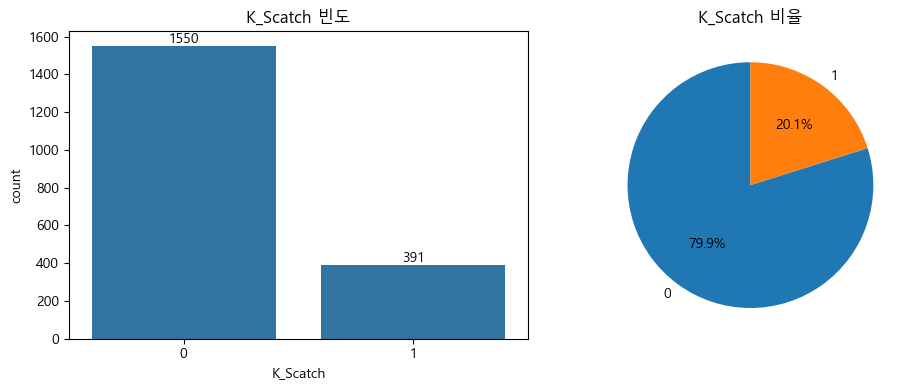

In [33]:
# 타겟 변수(K_Scatch) 빈도 및 클래스 불균형 확인
target_counts = Classification["K_Scatch"].value_counts().sort_index()
target_ratio = (target_counts / len(Classification) * 100).round(2)

print("클래스별 빈도")
print(target_counts)
print()
print("클래스별 비율(%)")
print(target_ratio)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(x="K_Scatch", data=Classification, ax=axes[0])
axes[0].set_title("K_Scatch 빈도")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                      ha="center", va="bottom")

axes[1].pie(target_ratio, labels=target_ratio.index, autopct="%.1f%%", startangle=90)
axes[1].set_title("K_Scatch 비율")

plt.tight_layout()
plt.show()

---
## B-2) 데이터 전처리

### B-2-1) 타겟 변수 정의

**[과제]** 써니는 K_Scatch를 분류 타겟(0/1)으로 사용하여 모델을 만들려고 합니다. 그런데 다른 결함 유형 변수들이 예측에 어떤 영향을 주는지 궁금해졌습니다. AI와 함께 각 결함 변수와 K_Scatch의 관계를 분석하고, 실제 공정 특성을 학습하기보다 정답을 미리 알려주는 역할을 하는 변수가 있는지 탐색해 보세요. 이후 이러한 변수들을 어떻게 처리하는 것이 적절할지 고민하고 적절한 전처리 방법을 적용해보세요.

In [ ]:
[프롬프트]

데이터셋에 결함유형을 알려주는 변수들이 있는데

1. 그 변수들이랑 타겟변수랑 관계를 분석하는 방법을 설명해주고
2. 관련 코드 짜줘

In [35]:
other_cols = ["Pastry", "Z_Scratch", "Stains", "Dirtiness", "Bumps", "Other_Faults"]

# 방법 1) "다른 6개가 전부 0일 때만 K_Scatch=1"이라는 규칙이 실제로 100% 맞는지 직접 검증
other_sum = Classification[other_cols].sum(axis=1)
rule_predicted = (other_sum == 0).astype(int)   # 다른 결함이 하나도 없으면 1, 하나라도 있으면 0

matches = (Classification["K_Scatch"] == rule_predicted).sum()
print(f"규칙과 실제 K_Scatch가 일치하는 행 : {matches} / {len(Classification)}")
# 전체 행 수와 같으면 -> 다른 6개 컬럼만으로 K_Scatch를 100% 맞출 수 있다는 뜻

# 방법 2) K_Scatch 값별로 다른 결함 컬럼들의 합을 groupby로 확인 (더 직관적)
Classification.groupby("K_Scatch")[other_cols].sum()

규칙과 실제 K_Scatch가 일치하는 행 : 1941 / 1941


,Pastry,Z_Scratch,Stains,Dirtiness,Bumps,Other_Faults
K_Scatch,,,,,,
0,158,190,72,55,402,673
1,0,0,0,0,0,0


In [ ]:
[프롬프트]

분석했더니 결함유형을 알려주는 변수에 한 번이라도 1이 있으면 타겟변수가 0인 구조였어.
이런 변수들을 어떻게 처리하는게 좋을지 추천해주고 코드 짜줘.

In [36]:
leak_cols = ["Pastry", "Z_Scratch", "Stains", "Dirtiness", "Bumps", "Other_Faults"]

# 데이터 누수 위험이 있는 결함 유형 컬럼 제거
Classification = Classification.drop(columns=leak_cols)

print("제거 후 데이터 크기 :", Classification.shape)
Classification.columns

제거 후 데이터 크기 : (1941, 28)


Index(['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas',
       'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity',
       'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer',
       'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness',
       'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index',
       'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas',
       'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index',
       'SigmoidOfAreas', 'K_Scatch'],
      dtype='object')

### B-2-2) 결측치 확인 및 데이터 분할

**[과제]** 써니는 데이터셋에 존재하는 클래스 불균형이 모델 학습과 평가에 영향을 줄 수 있다고 생각했습니다. AI와 함께 타겟 변수의 분포를 확인하고 원본 데이터의 클래스 비율이 학습 데이터와 테스트 데이터에도 유지될 수 있도록 적절한 데이터 분할 방법을 적용해 보세요.

In [ ]:
[프롬프트]

데이터셋은 클래스 불균형이 존재하고 분류 데이터야.
학습 및 테스트 데이터를 분할하려고 하는데 적절한 분할 방식에 따른 코드 짜줘.

In [ ]:
Y_cls = Classification["K_Scatch"]
X_cls = Classification.drop(columns=["K_Scatch"])

X_train_cls, X_test_cls, Y_train_cls, Y_test_cls = train_test_split(
    X_cls, Y_cls, test_size=0.3, stratify=Y_cls, random_state=0
)

print("학습 데이터 :", X_train_cls.shape)
print("테스트 데이터 :", X_test_cls.shape)

print("\n원본 클래스 비율(%)")
print((Y_cls.value_counts(normalize=True) * 100).round(2))

print("\n학습 데이터 클래스 비율(%)")
print((Y_train_cls.value_counts(normalize=True) * 100).round(2))

print("\n테스트 데이터 클래스 비율(%)")
print((Y_test_cls.value_counts(normalize=True) * 100).round(2))

학습 데이터 : (1358, 27)
테스트 데이터 : (583, 27)

원본 클래스 비율(%)
K_Scatch
0    79.86
1    20.14
Name: proportion, dtype: float64

학습 데이터 클래스 비율(%)
K_Scatch
0    79.82
1    20.18
Name: proportion, dtype: float64

테스트 데이터 클래스 비율(%)
K_Scatch
0    79.93
1    20.07
Name: proportion, dtype: float64


### B-2-3) 스케일링/인코딩 필요 여부 검토

**[과제]** 써니는 Day 2에서 로지스틱 회귀 모델 학습을 위해 스케일링을 적용했었습니다. 이번에 사용할 앙상블 모델들도 동일한 전처리가 필요한지 궁금해졌습니다. AI와 함께 모델별 특성을 살펴보고 스케일링과 인코딩이 필요한지 판단하여 적절한 전처리를 적용해 보세요.

In [ ]:
[프롬프트]

Classification 데이터셋에 대해서 스케일링이나 인코딩을 하려고 하는데
변수별 type을 추출해서 적절한 전처리를 검토해보고 싶어.

In [38]:
# 변수 타입 확인
print(X_cls.dtypes)
print()

# dtype별 변수 개수
print("dtype별 변수 개수")
print(X_cls.dtypes.value_counts())
print()

# 수치형 / 범주형(object, category) 변수 목록 분리
numeric_cols = X_cls.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_cls.select_dtypes(include=["object", "category"]).columns.tolist()

print("수치형 변수 (%d개) :" % len(numeric_cols), numeric_cols)
print("범주형 변수 (%d개) :" % len(categorical_cols), categorical_cols)

X_Minimum                  int64
X_Maximum                  int64
Y_Minimum                  int64
Y_Maximum                  int64
Pixels_Areas               int64
X_Perimeter                int64
Y_Perimeter                int64
Sum_of_Luminosity          int64
Minimum_of_Luminosity      int64
Maximum_of_Luminosity      int64
Length_of_Conveyer         int64
TypeOfSteel_A300           int64
TypeOfSteel_A400           int64
Steel_Plate_Thickness      int64
Edges_Index              float64
Empty_Index              float64
Square_Index             float64
Outside_X_Index          float64
Edges_X_Index            float64
Edges_Y_Index            float64
Outside_Global_Index     float64
LogOfAreas               float64
Log_X_Index              float64
Log_Y_Index              float64
Orientation_Index        float64
Luminosity_Index         float64
SigmoidOfAreas           float64
dtype: object

dtype별 변수 개수
int64      14
float64    13
Name: count, dtype: int64

수치형 변수 (27개) : ['X_Minimum

In [ ]:
[프롬프트]

모두 수치형 변수인 데이터셋이어서 스케일링만 하면 될 것 같아.

어제는 로지스틱 회귀 모델로 분류 데이터셋을 학습시켰는데
오늘은 앙상블 모델로 학습시켜보려고해.

어떤 스케일링을 하면 좋을지 이유와 함께 추천해줘.

---
## B-3) 모델 학습 및 예측

**[과제]** 써니는 Day 2에서 학습한 회귀 모델과 Day 3에서 학습한 앙상블 모델을 동일한 데이터셋에 적용하여 성능을 비교해 보고자 합니다. AI와 함께 모델 학습, 예측, 성능 평가 코드를 작성하고, 여러 모델의 결과를 한눈에 비교할 수 있는 방법을 찾아 성능을 비교 및 분석해 보세요.

In [ ]:
[프롬프트]

어제는 로지스틱 회귀랑 분류 나무를 배웠고 오늘은 앙상블 모델 Random Forest, GBM, XGBoost, LGBM, CatBoost를 배웠어.

1. 모든 모델에 대한 학습, 예측, 성능 평가 모델 코드를 짜주고
2. 여러 모델의 결과를 한눈에 비교할 수 있는 코드도 짜줘.

In [39]:
# 선형계열(로지스틱회귀)만 스케일링, 트리/앙상블 계열은 원본 그대로 사용
scaler_cls = StandardScaler()
X_train_cls_scaled = scaler_cls.fit_transform(X_train_cls)
X_test_cls_scaled = scaler_cls.transform(X_test_cls)

# 분류 성능 평가 함수
def get_clsscore(true, pred):
    return {
        "Accuracy": accuracy_score(true, pred),
        "Precision": precision_score(true, pred),
        "Recall": recall_score(true, pred),
        "F1": f1_score(true, pred),
    }

# (모델 인스턴스, 스케일링 필요 여부)
models_cls = {
    "LogisticRegression": (LogisticRegression(max_iter=1000), True),
    "DecisionTree": (DecisionTreeClassifier(random_state=0), False),
    "RandomForest": (RandomForestClassifier(random_state=0), False),
    "GBM": (GradientBoostingClassifier(random_state=0), False),
    "XGBoost": (XGBClassifier(random_state=0), False),
    "LightGBM": (LGBMClassifier(random_state=0, verbose=-1), False),
    "CatBoost": (CatBoostClassifier(random_state=0, verbose=0), False),
}

cls_results = []
cls_preds = {}

for name, (model, needs_scaling) in models_cls.items():
    X_tr = X_train_cls_scaled if needs_scaling else X_train_cls
    X_te = X_test_cls_scaled if needs_scaling else X_test_cls

    model.fit(X_tr, Y_train_cls)
    pred = model.predict(X_te)
    cls_preds[name] = pred

    score = get_clsscore(Y_test_cls, pred)
    score["Model"] = name
    cls_results.append(score)

    print(f"[{name}]")
    print("Accuracy  : %.3f" % score["Accuracy"])
    print("Precision : %.3f" % score["Precision"])
    print("Recall    : %.3f" % score["Recall"])
    print("F1        : %.3f" % score["F1"])
    print()

[LogisticRegression]
Accuracy  : 0.967
Precision : 0.945
Recall    : 0.889
F1        : 0.916

[DecisionTree]
Accuracy  : 0.964
Precision : 0.929
Recall    : 0.889
F1        : 0.908

[RandomForest]
Accuracy  : 0.974
Precision : 0.964
Recall    : 0.906
F1        : 0.934

[GBM]
Accuracy  : 0.973
Precision : 0.963
Recall    : 0.897
F1        : 0.929

[XGBoost]
Accuracy  : 0.976
Precision : 0.956
Recall    : 0.923
F1        : 0.939

[LightGBM]
Accuracy  : 0.978
Precision : 0.956
Recall    : 0.932
F1        : 0.944

[CatBoost]
Accuracy  : 0.974
Precision : 0.964
Recall    : 0.906
F1        : 0.934



                Model  Accuracy  Precision  Recall     F1
0            LightGBM     0.978      0.956   0.932  0.944
1             XGBoost     0.976      0.956   0.923  0.939
2        RandomForest     0.974      0.964   0.906  0.934
3            CatBoost     0.974      0.964   0.906  0.934
4                 GBM     0.973      0.963   0.897  0.929
5  LogisticRegression     0.967      0.945   0.889  0.916
6        DecisionTree     0.964      0.929   0.889  0.908


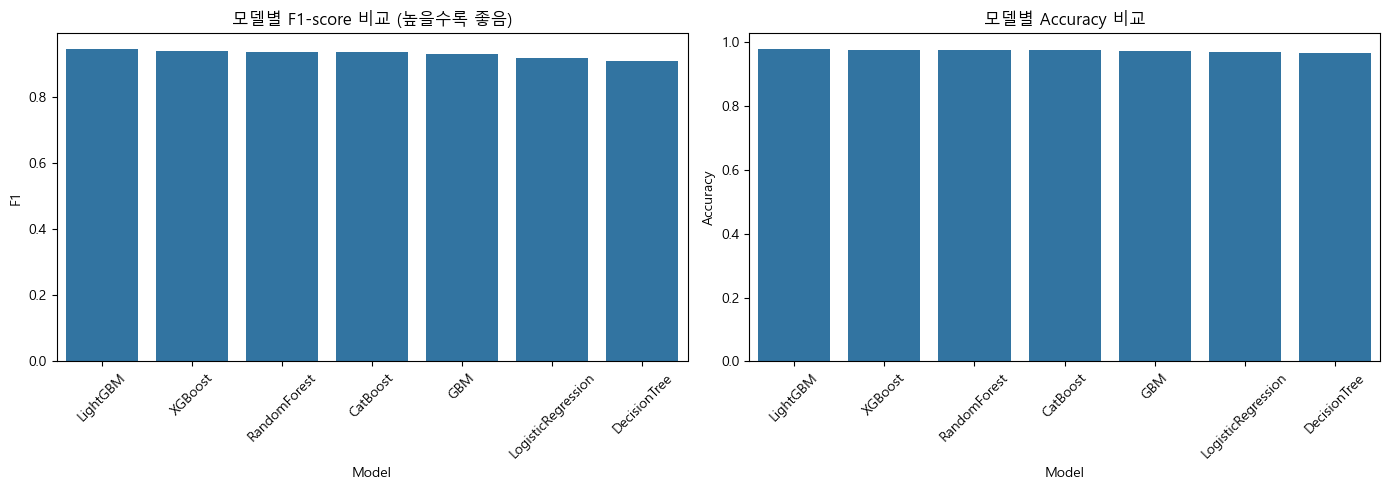

In [40]:
# 여러 모델 결과 한눈에 비교
cls_compare = pd.DataFrame(cls_results)[["Model", "Accuracy", "Precision", "Recall", "F1"]].round(3)
cls_compare = cls_compare.sort_values(by="F1", ascending=False).reset_index(drop=True)
print(cls_compare)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x="Model", y="F1", data=cls_compare, ax=axes[0])
axes[0].set_title("모델별 F1-score 비교 (높을수록 좋음)")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(x="Model", y="Accuracy", data=cls_compare, ax=axes[1])
axes[1].set_title("모델별 Accuracy 비교")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

---
## B-5) 모델 결과 분석 및 고도화

**[과제]** 써니는 클래스 불균형이 성능에 영향을 줄 수 있다고 생각했습니다. 다만 모델마다 불균형을 다루는 방식이 다르다는 것을 알게 되었습니다. AI와 함께 각 모델에 맞는 불균형 완화 방법을 적용하고 적용 전후 성능을 비교해 보세요.

> 예:Random Forest는 `class_weight`, GBM은 `sample_weight`, XGBoost는 `scale_pos_weight`, LightGBM은 `is_unbalance`, CatBoost는 `auto_class_weights`

In [ ]:
[프롬프트]

클래스 불균형이 존재하는 데이터셋이다보니까
내가 방금 돌렸던 모델들의 하이퍼라라미터 중에 불균형을 해결해주는 하이퍼파라미터를 추가해서 개선하고 싶어.

1. 모델별 해당 하이퍼라라미터에 대해 아주 쉽게 한줄 설명해주고
2. 코드 짜줘.

In [41]:
# XGBoost scale_pos_weight 및 GBM sample_weight용 비율 계산
neg, pos = Y_train_cls.value_counts()[0], Y_train_cls.value_counts()[1]
scale_pos_weight = neg / pos

models_cls_balanced = {
    "LogisticRegression": (LogisticRegression(max_iter=1000, class_weight="balanced"), True),
    "DecisionTree": (DecisionTreeClassifier(random_state=0, class_weight="balanced"), False),
    "RandomForest": (RandomForestClassifier(random_state=0, class_weight="balanced"), False),
    "GBM": (GradientBoostingClassifier(random_state=0), False),
    "XGBoost": (XGBClassifier(random_state=0, scale_pos_weight=scale_pos_weight), False),
    "LightGBM": (LGBMClassifier(random_state=0, verbose=-1, is_unbalance=True), False),
    "CatBoost": (CatBoostClassifier(random_state=0, verbose=0, auto_class_weights="Balanced"), False),
}

# GBM은 class_weight가 없어서 sample_weight로 대신 가중치 부여
sample_weight_gbm = Y_train_cls.map({0: 1.0, 1: scale_pos_weight})

cls_results_balanced = []

for name, (model, needs_scaling) in models_cls_balanced.items():
    X_tr = X_train_cls_scaled if needs_scaling else X_train_cls
    X_te = X_test_cls_scaled if needs_scaling else X_test_cls

    if name == "GBM":
        model.fit(X_tr, Y_train_cls, sample_weight=sample_weight_gbm)
    else:
        model.fit(X_tr, Y_train_cls)

    pred = model.predict(X_te)
    score = get_clsscore(Y_test_cls, pred)
    score["Model"] = name
    cls_results_balanced.append(score)

    print(f"[{name} (불균형 보정 후)]")
    print("Accuracy  : %.3f" % score["Accuracy"])
    print("Precision : %.3f" % score["Precision"])
    print("Recall    : %.3f" % score["Recall"])
    print("F1        : %.3f" % score["F1"])
    print()

# 적용 전 / 후 성능 비교
before = pd.DataFrame(cls_results)[["Model", "Accuracy", "Precision", "Recall", "F1"]].set_index("Model").add_suffix("_전")
after = pd.DataFrame(cls_results_balanced)[["Model", "Accuracy", "Precision", "Recall", "F1"]].set_index("Model").add_suffix("_후")

compare_balanced = before.join(after).round(3)
compare_balanced

[LogisticRegression (불균형 보정 후)]
Accuracy  : 0.961
Precision : 0.873
Recall    : 0.940
F1        : 0.905

[DecisionTree (불균형 보정 후)]
Accuracy  : 0.973
Precision : 0.947
Recall    : 0.915
F1        : 0.930

[RandomForest (불균형 보정 후)]
Accuracy  : 0.969
Precision : 0.963
Recall    : 0.880
F1        : 0.920

[GBM (불균형 보정 후)]
Accuracy  : 0.971
Precision : 0.963
Recall    : 0.889
F1        : 0.924

[XGBoost (불균형 보정 후)]
Accuracy  : 0.979
Precision : 0.965
Recall    : 0.932
F1        : 0.948

[LightGBM (불균형 보정 후)]
Accuracy  : 0.976
Precision : 0.956
Recall    : 0.923
F1        : 0.939

[CatBoost (불균형 보정 후)]
Accuracy  : 0.978
Precision : 0.964
Recall    : 0.923
F1        : 0.943



,Accuracy_전,Precision_전,Recall_전,F1_전,Accuracy_후,Precision_후,Recall_후,F1_후
Model,,,,,,,,
LogisticRegression,0.967,0.945,0.889,0.916,0.961,0.873,0.940,0.905
DecisionTree,0.964,0.929,0.889,0.908,0.973,0.947,0.915,0.930
RandomForest,0.974,0.964,0.906,0.934,0.969,0.963,0.880,0.920
GBM,0.973,0.963,0.897,0.929,0.971,0.963,0.889,0.924
XGBoost,0.976,0.956,0.923,0.939,0.979,0.965,0.932,0.948
LightGBM,0.978,0.956,0.932,0.944,0.976,0.956,0.923,0.939
CatBoost,0.974,0.964,0.906,0.934,0.978,0.964,0.923,0.943


**[과제]** 써니는 불균형 완화까지 적용한 5개 모델의 변수 중요도를 비교해서, K_Scatch 결함 여부에 공통적으로 큰 영향을 주는 변수가 무엇인지 확인하려고 합니다. AI와 상의해서 비교 시각화를 만들어 보세요.

In [ ]:
[프롬프트]

불균형 완화를 적용한 앙상블 모델에 대해서만 변수 중요도를 비교해서
K_Scatch 결함 여부에 공통적으로 큰 영향을 주는 변수가 무엇인지 궁금해.

시각화할 수 있는 코드 짜줘.

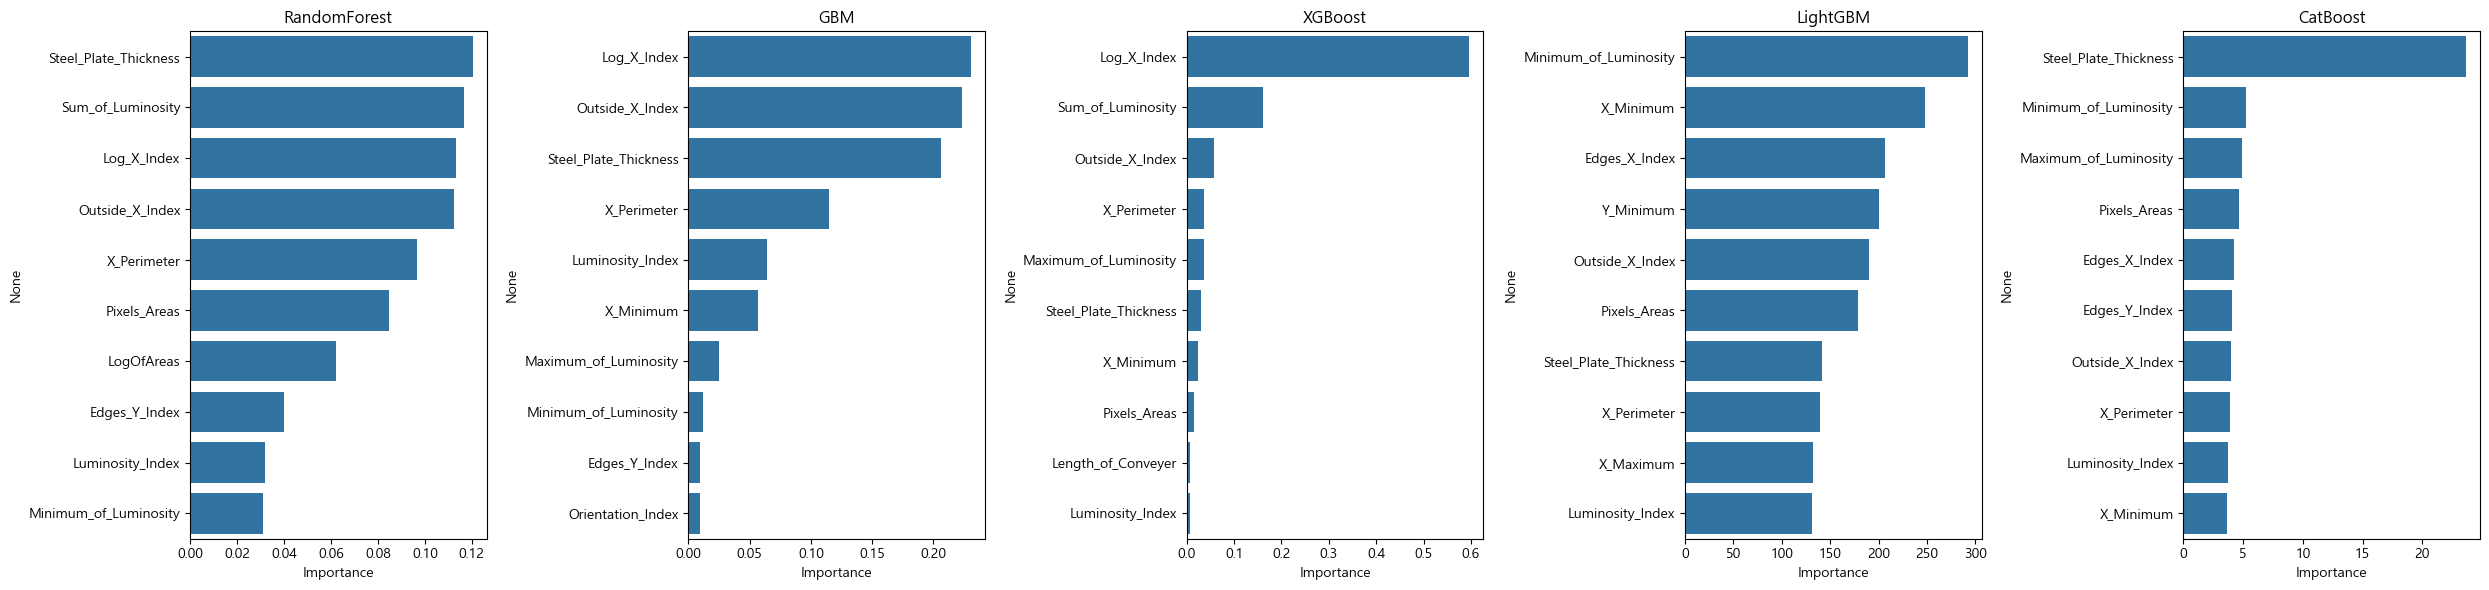

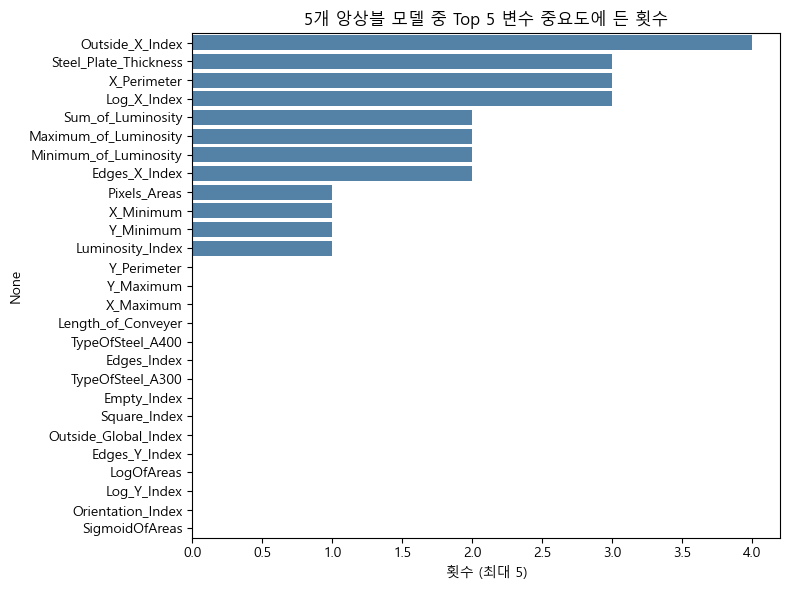

5개 모델 중 Top 5 안에 든 횟수
Outside_X_Index          4
Steel_Plate_Thickness    3
X_Perimeter              3
Log_X_Index              3
Sum_of_Luminosity        2
Maximum_of_Luminosity    2
Minimum_of_Luminosity    2
Edges_X_Index            2
Pixels_Areas             1
X_Minimum                1
Y_Minimum                1
Luminosity_Index         1
Y_Perimeter              0
Y_Maximum                0
X_Maximum                0
Length_of_Conveyer       0
TypeOfSteel_A400         0
Edges_Index              0
TypeOfSteel_A300         0
Empty_Index              0
Square_Index             0
Outside_Global_Index     0
Edges_Y_Index            0
LogOfAreas               0
Log_Y_Index              0
Orientation_Index        0
SigmoidOfAreas           0
dtype: int64


In [42]:
ensemble_models_balanced = ["RandomForest", "GBM", "XGBoost", "LightGBM", "CatBoost"]

# 불균형 완화 적용된 5개 앙상블 모델의 변수 중요도 추출
importance_dict_cls = {
    name: pd.Series(models_cls_balanced[name][0].feature_importances_, index=X_cls.columns)
    for name in ensemble_models_balanced
}
importance_df_cls = pd.DataFrame(importance_dict_cls)

# 1. 모델별 변수 중요도 Top 10 (subplot)
fig, axes = plt.subplots(1, len(ensemble_models_balanced), figsize=(5 * len(ensemble_models_balanced), 6))

for ax, name in zip(axes, ensemble_models_balanced):
    top10 = importance_df_cls[name].sort_values(ascending=False).head(10)
    sns.barplot(x=top10.values, y=top10.index, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

# 2. 5개 모델 중 Top 5 안에 몇 번 들었는지 (공통적으로 중요한 변수)
top5_count_cls = (importance_df_cls.rank(ascending=False) <= 5).sum(axis=1).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=top5_count_cls.values, y=top5_count_cls.index, color="steelblue")
plt.title("5개 앙상블 모델 중 Top 5 변수 중요도에 든 횟수")
plt.xlabel("횟수 (최대 5)")
plt.tight_layout()
plt.show()

print("5개 모델 중 Top 5 안에 든 횟수")
print(top5_count_cls)


**[과제]** 써니는 불균형 완화 이후 F1-score가 가장 좋았던 모델의 성능을 하이퍼파라미터 튜닝으로 더 끌어올리고 싶습니다. AI와 함께 적절한 탐색 범위를 설정하여 GridSearchCV로 성능을 개선해 보세요.

In [ ]:
[프롬프트]

확인해보니 XGBoost의 성능이 가장 좋았어.

1. XGBoost의 주요 하이퍼파라미터에 대해 아주 쉽게 설명해주고
2. 적절한 탐색 범위를 추천해주고
3. 이에 대한 GridSearch 코드 짜줘.

In [43]:
from sklearn.model_selection import GridSearchCV

xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

# 클래스 불균형 보정은 유지한 채로 나머지 하이퍼파라미터만 탐색
xgb_base = XGBClassifier(random_state=0, scale_pos_weight=scale_pos_weight)

xgb_grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_param_grid,
    scoring="f1",      # 불균형 데이터이므로 accuracy 대신 f1 기준으로 최적화
    cv=5,
    n_jobs=-1,
)

xgb_grid.fit(X_train_cls, Y_train_cls)

print("최적 하이퍼파라미터 :", xgb_grid.best_params_)
print("최적 CV F1-score   : %.3f" % xgb_grid.best_score_)

# 최적 모델로 테스트 데이터 성능 확인
best_xgb = xgb_grid.best_estimator_
pred_best_xgb = best_xgb.predict(X_test_cls)

score_best_xgb = get_clsscore(Y_test_cls, pred_best_xgb)
print("\n[XGBoost (튜닝 후)] 테스트 성능")
for k, v in score_best_xgb.items():
    print(f"{k} : {v:.3f}")

최적 하이퍼파라미터 : {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
최적 CV F1-score   : 0.969

[XGBoost (튜닝 후)] 테스트 성능
Accuracy : 0.978
Precision : 0.964
Recall : 0.923
F1 : 0.943
